# Randomisation Inference Simulation

Compares two inferential approaches for each assignment design:

| Approach | SE source | Valid for BWD? |
|---|---|---|
| **Neyman** | Sample variances (ignores design) | Conservative — overcoverage, lower power |
| **Randomisation Inference** | Re-run BWD B times | Exploits known assignment mechanism |

Metrics measured per design per iteration:
- `NeymanCoverage` / `RI_Coverage` — does the 95% CI contain the true ATE?
- `NeymanRejects` / `RI_Rejects` — do we reject H0: tau=0 when a real effect exists?
- `ATEError` — bias of the point estimate
- `CovariateMSE` — covariate imbalance between groups

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

import evaluator as evl
from alias import bal, dgp, est
from plan import Plan

In [3]:
# ── Simulation parameters ─────────────────────────────────────────────────────
B = 500  # RI re-runs per experiment
NUM_ITERS = 500  # repetitions per (design, sample_size, dgp) cell
# increase to 500 for final thesis results

sample_sizes = [100, 250, 500, 1000]

In [4]:
# The RI evaluators are registered once with balancer_class=bal.BWD.
# They re-run BWD internally regardless of which design ran the real experiment,
# so we can compare RI against Neyman across all designs on equal footing.

bwd_kwargs = {"phi": 1.0, "delta": 0.05}

plan = Plan()

# Designs
plan.add_design("Simple", bal.Simple, est.DifferenceInMeans, {})
plan.add_design("BWD(1)", bal.BWD, est.DifferenceInMeans, {"phi": 1.0})
plan.add_design("BWD(0.5)", bal.BWD, est.DifferenceInMeans, {"phi": 0.5})

# Standard metrics
plan.add_evaluator("ATEError", evl.ATEError)
plan.add_evaluator("CovariateMSE", evl.CovariateMSE)
plan.add_evaluator("CISize", evl.CISize)

# Neyman inference (baseline)
plan.add_evaluator("NeymanCoverage", evl.ATECovers)  # fixed bug
plan.add_evaluator("NeymanRejects", evl.NeymanRejects)

# Randomisation inference
ri_kwargs = {"balancer_class": bal.BWD, "balancer_kwargs": bwd_kwargs, "B": B}
plan.add_evaluator("RI_PValue", evl.RandomisationInferencePValue, ri_kwargs)
plan.add_evaluator("RI_Rejects", evl.RandomisationInferenceRejects, ri_kwargs)
plan.add_evaluator("RI_Coverage", evl.RandomisationInferenceCoverage, ri_kwargs)

In [6]:
os.makedirs("../results/inference", exist_ok=True)
dfs = []
for sample_size in sample_sizes:
    print(f"\nSample size: {sample_size}", flush=True)
    dgp_factories = [dgp.LinearFactory(N=sample_size, pate=0.1)]
    for factory in dgp_factories:
        dgp_name = type(factory.create_dgp()).__name__
        # print(f"  DGP: {dgp_name}", flush=True)
        for it in tqdm(range(NUM_ITERS)):
            result = plan.execute(factory, seed=it * 1001)
            result["iteration"] = it
            result["sample_size"] = sample_size
            result["dgp"] = dgp_name
            dfs.append(result)


Sample size: 100


100%|██████████| 500/500 [08:56<00:00,  1.07s/it]


Sample size: 250



100%|██████████| 500/500 [20:01<00:00,  2.40s/it]


Sample size: 500



100%|██████████| 500/500 [1:10:50<00:00,  8.50s/it]   


Sample size: 1000



100%|██████████| 500/500 [2:21:09<00:00, 16.94s/it]   


In [7]:
results = pd.concat(dfs, ignore_index=True)

In [ ]:
summary = (
    results.groupby(["dgp", "sample_size", "design", "metric"])["value"]
    .agg(mean="mean", se=lambda x: x.std() / np.sqrt(len(x)))
    .reset_index()
)

key_metrics = [
    "NeymanCoverage",
    "RI_Coverage",
    "NeymanRejects",
    "RI_Rejects",
    "CISize",
    "CovariateMSE",
]
(
    summary[summary["metric"].isin(key_metrics)]
    .pivot_table(index=["sample_size", "design"], columns="metric", values="mean")
    .round(3)
)

metric                CISize  CovariateMSE  NeymanCoverage  NeymanRejects  \
sample_size design                                                          
100         BWD(0.5)   0.448         0.005           0.998          0.134   
            BWD(1)     0.448         0.003           1.000          0.074   
            Simple     0.449         0.008           0.952          0.150   
250         BWD(0.5)   0.284         0.001           1.000          0.220   
            BWD(1)     0.284         0.001           1.000          0.180   
            Simple     0.284         0.003           0.928          0.322   
500         BWD(0.5)   0.199         0.000           0.998          0.520   
            BWD(1)     0.199         0.000           1.000          0.528   
            Simple     0.199         0.002           0.954          0.578   
1000        BWD(0.5)   0.141         0.000           1.000          0.912   
            BWD(1)     0.141         0.000           1.000          0.944   
            Simple     0.141         0.001           0.956          0.804   

metric                RI_Coverage  RI_Rejects  
sample_size design                             
100         BWD(0.5)        0.868       0.350  
            BWD(1)          0.962       0.300  
            Simple          0.818       0.350  
250         BWD(0.5)        0.852       0.802  
            BWD(1)          0.960       0.832  
            Simple          0.598       0.744  
500         BWD(0.5)        0.856       0.974  
            BWD(1)          0.986       1.000  
            Simple          0.510       0.910  
1000        BWD(0.5)        0.862       1.000  
            BWD(1)          0.974       1.000  
            Simple          0.442       0.980

In [10]:
summary_table = (
    summary[summary["metric"].isin(key_metrics)]
    .pivot_table(index=["sample_size", "design"], columns="metric", values="mean")
    .round(3)
)
summary_table.to_csv("../results/tables/inference_summary.csv")

In [12]:
summary_table = (
    summary[summary["metric"].isin(key_metrics)]
    .pivot_table(index=["sample_size", "design"], columns="metric", values="mean")
    .round(3)
)
summary_table.to_markdown("../results/tables/inference_summary.md")

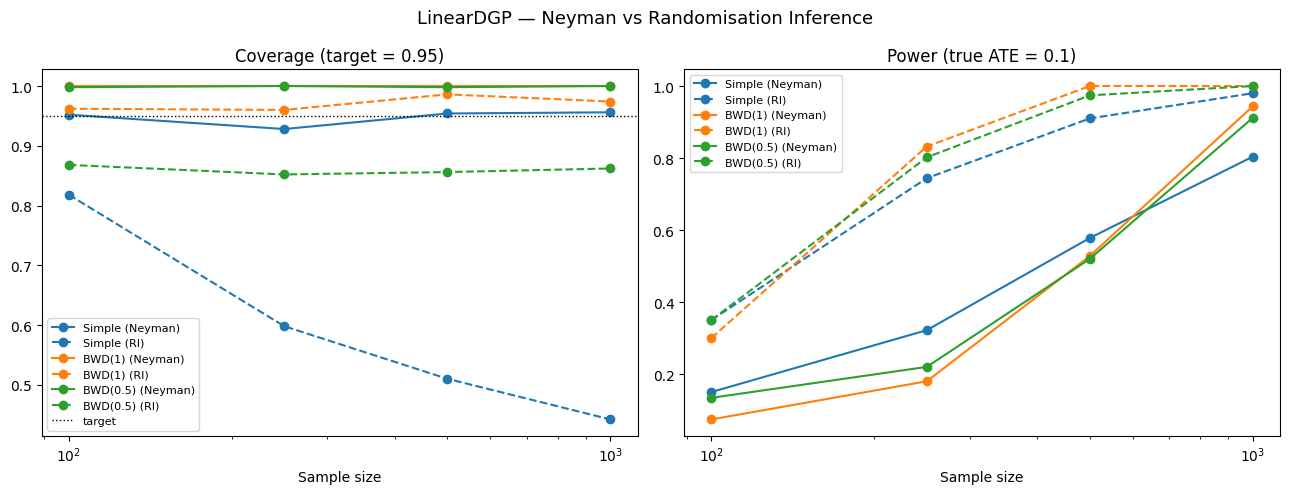

In [9]:
designs = results["design"].unique()
colors = plt.cm.tab10.colors
design_color = dict(zip(designs, colors, strict=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("LinearDGP — Neyman vs Randomisation Inference", fontsize=13)

for ax, (neyman_m, ri_m, title, target) in zip(
    axes,
    [
        ("NeymanCoverage", "RI_Coverage", "Coverage (target = 0.95)", 0.95),
        ("NeymanRejects", "RI_Rejects", "Power (true ATE = 0.1)", None),
    ],
    strict=False,
):
    for design in designs:
        color = design_color[design]
        for metric, ls, label_suffix in [
            (neyman_m, "-", "(Neyman)"),
            (ri_m, "--", "(RI)"),
        ]:
            sub = summary[(summary["metric"] == metric) & (summary["design"] == design)]
            ax.plot(
                sub["sample_size"],
                sub["mean"],
                color=color,
                linestyle=ls,
                marker="o",
                label=f"{design} {label_suffix}",
            )
    if target:
        ax.axhline(target, color="black", linestyle=":", linewidth=1, label="target")
    ax.set_title(title)
    ax.set_xlabel("Sample size")
    ax.set_xscale("log")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    "../results/figures/inference_coverage_power.png", dpi=150, bbox_inches="tight"
)
plt.show()